In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# define all constants here
pattern_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8]
G_dim = len(pattern_ids)
G_prob = 1/G_dim
x_sigma = .1
I_sigma = 20
offset = 0
G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 100
n_draws = 100
n_chains = 1
n_cores = 1

In [3]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")
exc_images = np.load(exc_fname)
exc_images_mean = exc_images.mean(axis=0)
exc_images = exc_images - exc_images_mean
vmin = np.min(exc_images)
vmax = np.max(exc_images)

In [4]:
results = center_surround_experiment(
    seed=seed,
    patterns=exc_images[pattern_ids],
    g_dim=G_dim,
    g_prob=G_prob,
    x_sigma=x_sigma,
    i_sigma=I_sigma,
    patterns_offset=offset,
    n_tune=n_tune,
    n_draws=n_draws,
    n_chains=n_chains,
    n_cores=n_cores
)

Only 100 samples in chain.


Running experiment with config:
seed=42, g_dim=9, g_prob=0.1111111111111111, x_sigma=0.1, i_sigma=20, pattern_offset=0, n_tune=100, n_draws=100, n_chains=1, n_cores=1
Building model ...
Setting up experiment ...
Number of center x dims:  9
Running experiment for center x dim 0/9 ...
Sampling posterior for MEI ...


Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


In [5]:
(
    model,
    all_idata,
    all_stimuli,
    all_g_means,
    all_g_means_sde,
    all_center_x_means,
    all_center_x_means_sde,
    all_center_x_perc_change_means,
    all_center_x_perc_change_means_sde,
) = results

In [6]:
len(all_stimuli)

9

In [7]:
["Com"] + ["Dis"] * 8

['Com', 'Dis', 'Dis', 'Dis', 'Dis', 'Dis', 'Dis', 'Dis', 'Dis']

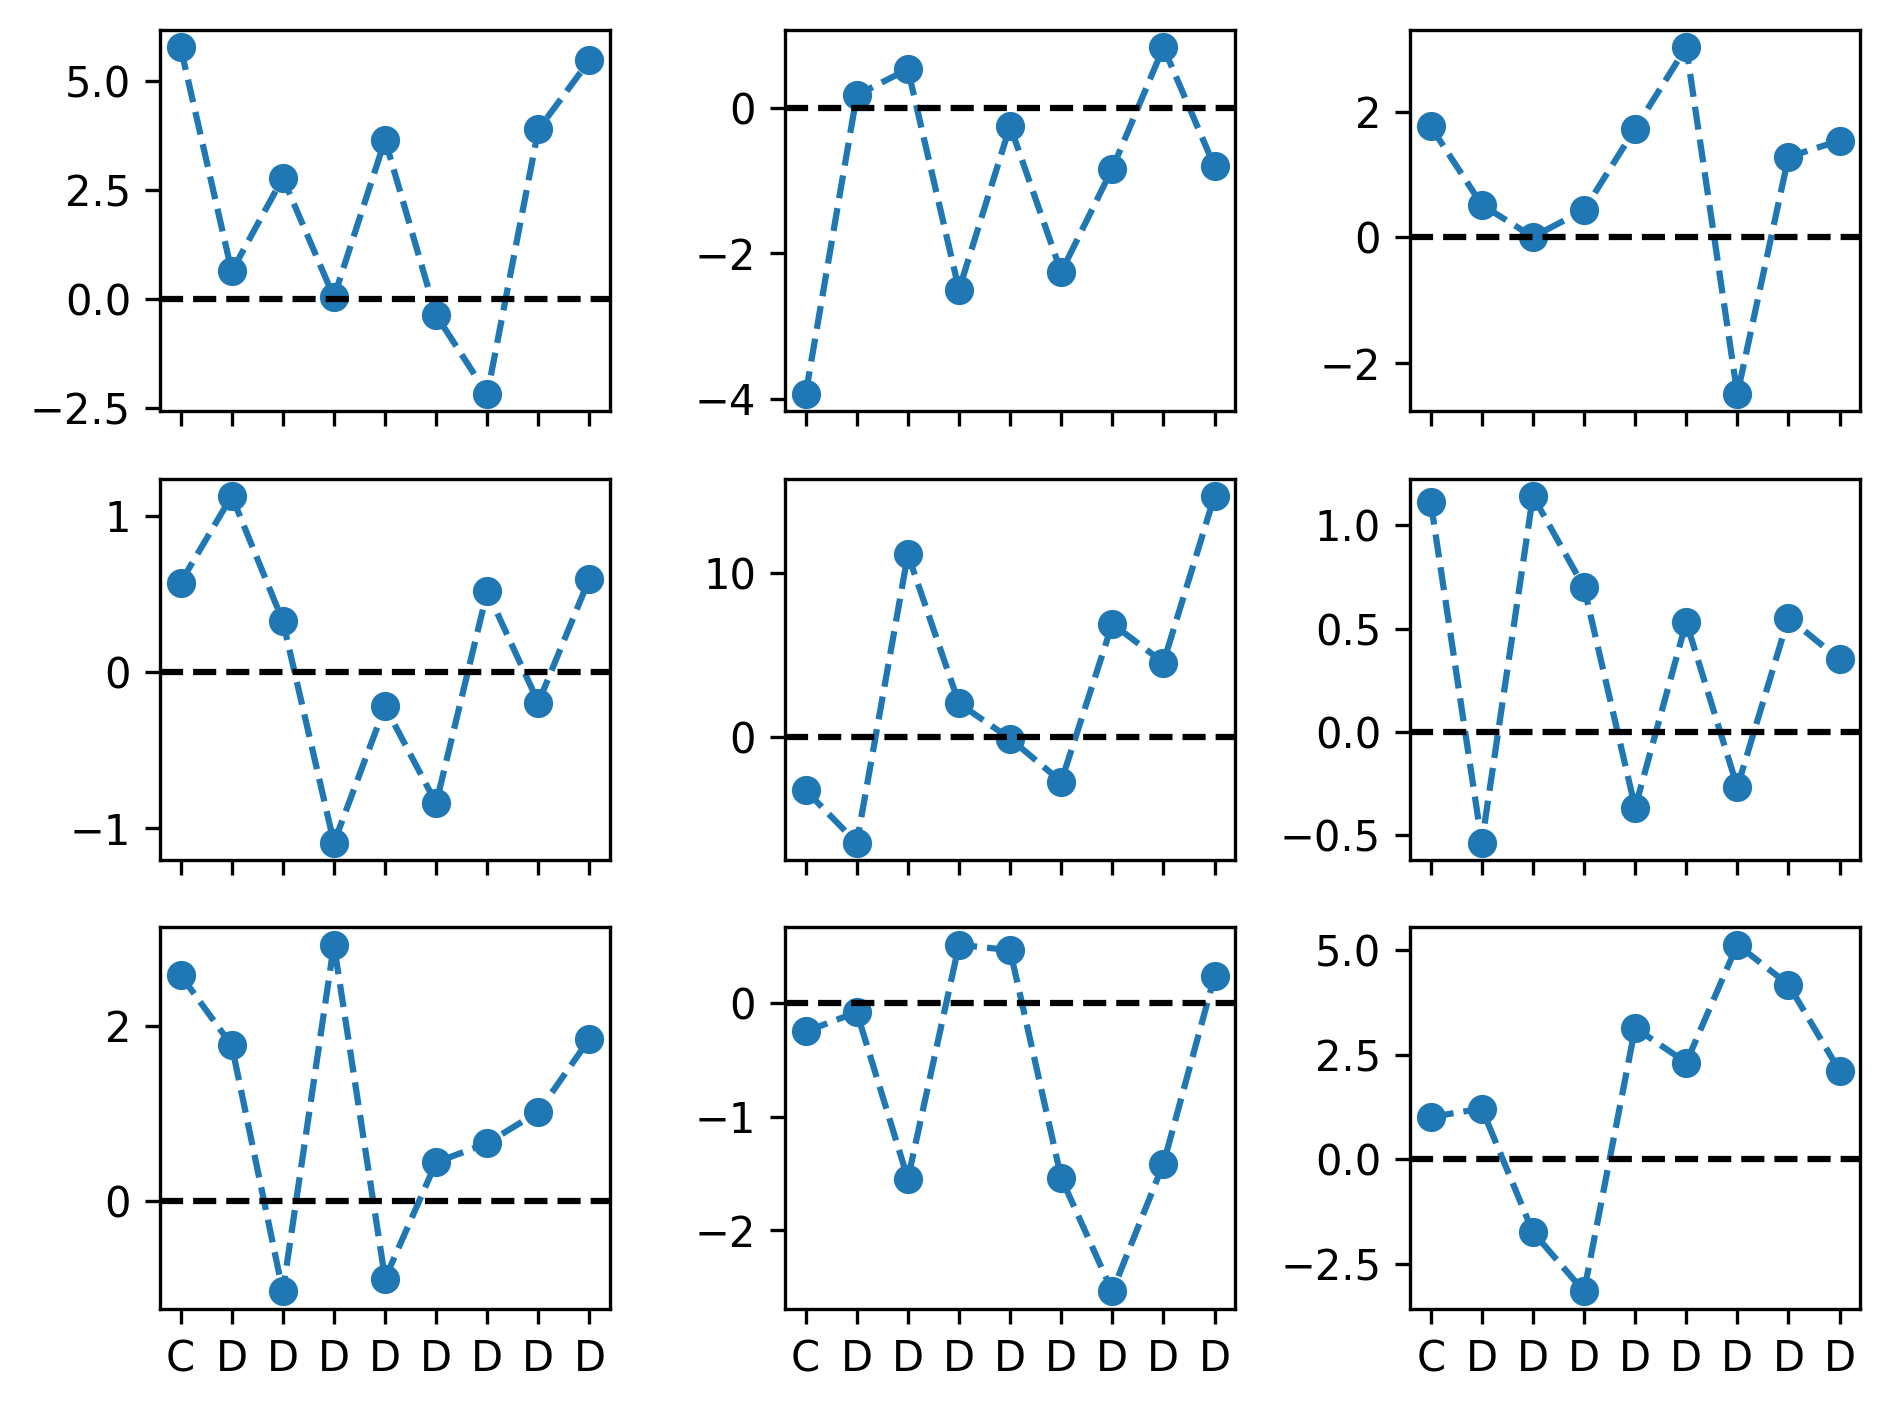

In [8]:
fig, axs = plt.subplots(dpi=300, nrows=3, ncols=3, sharex=True, tight_layout=True)
for means, ax in zip(all_center_x_perc_change_means, axs.flatten()):
    ax.plot(means, "--o")
    # draw a horizontal line at 0
    ax.axhline(y=0, color="black", linestyle="--")
    ax.set_xticks(range(0, 9))
    ax.set_xticklabels(["C"] + ["D"] * 8)
    # ax.set_xticklabels(["Com"] + ["Dis"] * 8)
    # ax.set_xticklabels(range(9))

TypeError: Invalid shape (2, 36, 36) for image data

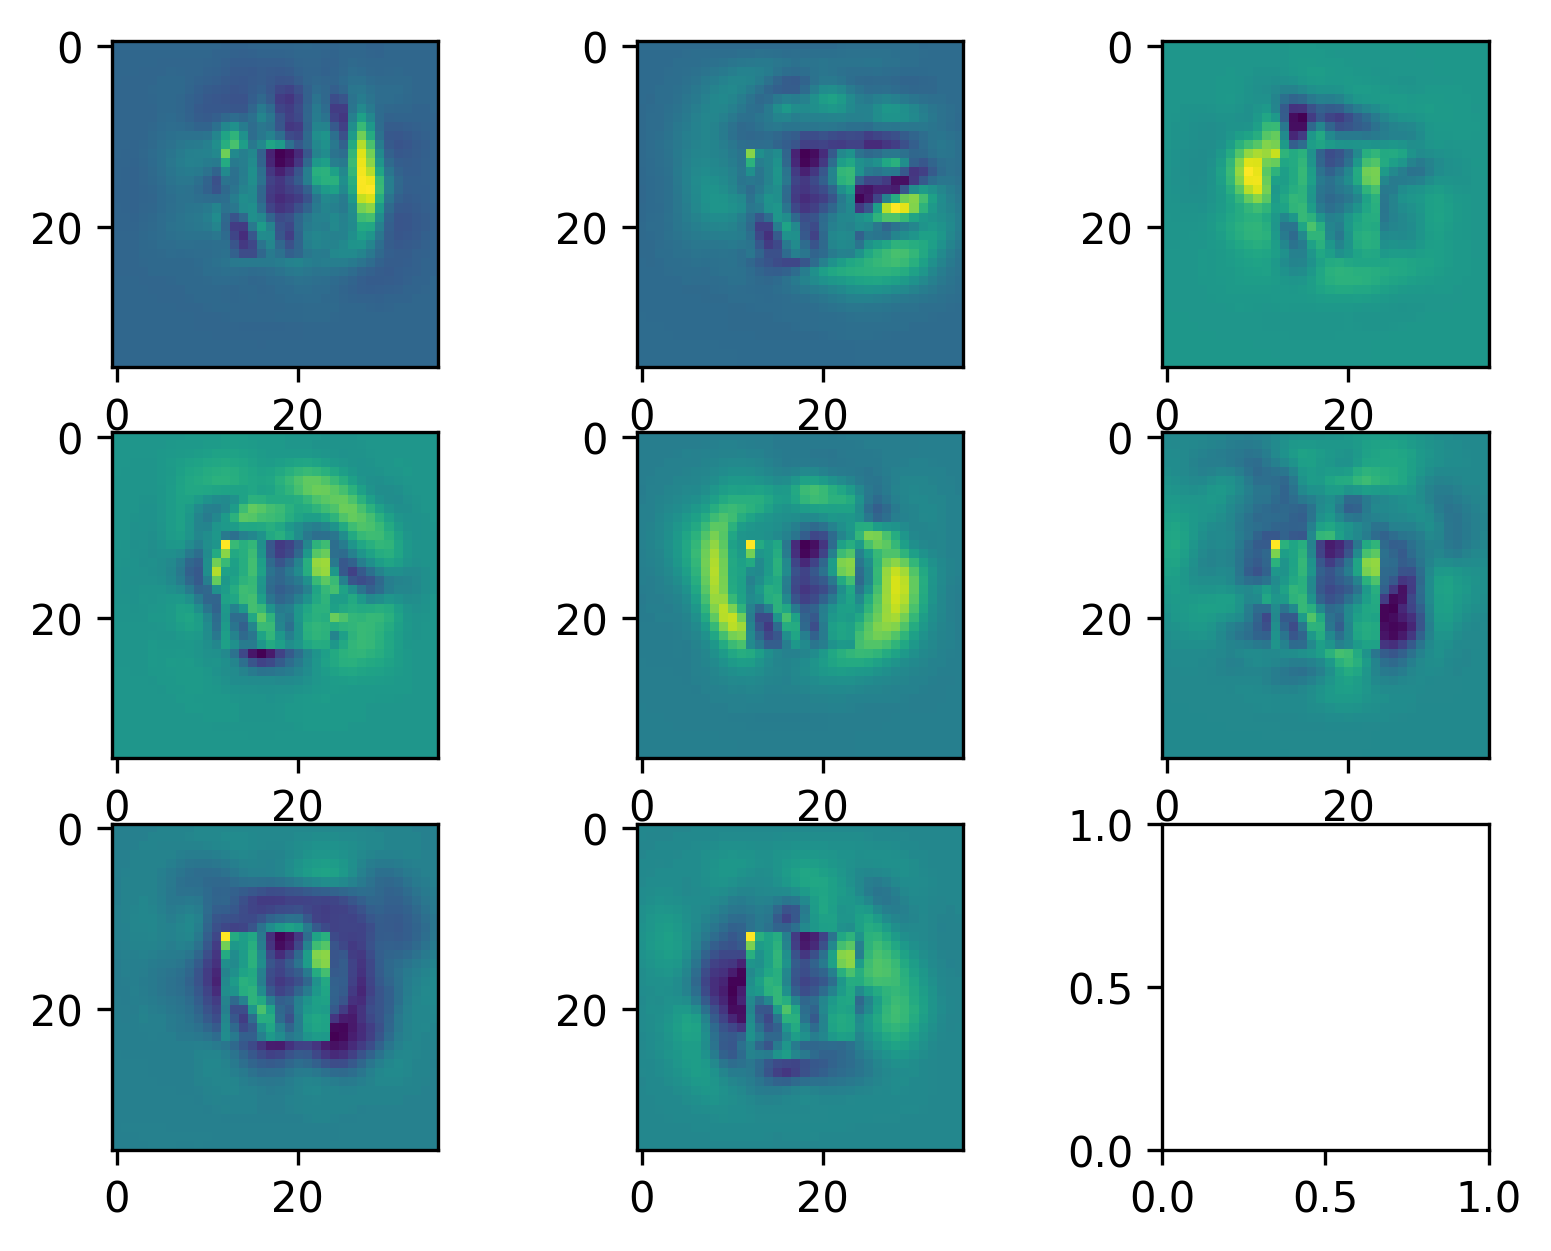

In [47]:
fig, axs = plt.subplots(dpi=300, nrows=3, ncols=3)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(all_stimuli[81 - 9 + idx])

In [15]:
all_center_x_perc_change_means

[[5.781700033520329,
  0.6388623662203199,
  2.784612669510136,
  0.047350081974329584,
  3.6597569723395216,
  -0.36568690550382965,
  -2.177224146330339,
  3.896509669449593,
  5.482308293643962],
 [-3.9392650683127464,
  0.1786534559327659,
  0.5369249060254004,
  -2.502169921883809,
  -0.2446278206845675,
  -2.25885223655534,
  -0.8332593362079437,
  0.8373859628055643,
  -0.8024676863389637],
 [1.7656673443426467,
  0.5190443350689568,
  0.010629953279948054,
  0.4353024094093013,
  1.7293462105833353,
  3.023271312979312,
  -2.490595363034232,
  1.2804460921743077,
  1.5408458035643755],
 [0.5713812733045953,
  1.12488121650093,
  0.324510013619636,
  -1.0945795858005405,
  -0.22169413666356186,
  -0.8414324213569462,
  0.5145614903819204,
  -0.1969489004540012,
  0.596609196937795],
 [-3.2612993307917226,
  -6.477357060910803,
  11.162407219757638,
  2.0487714118723432,
  -0.10195184378830949,
  -2.729733288406437,
  6.919283951016873,
  4.550751738201188,
  14.73882159664737],


In [8]:
all_center_x_perc_change_means_sde

[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

In [4]:
# model_images = exc_images[-G_dim:]
model_images = exc_images[pattern_ids]
model = PatternCompletionModel(
    patterns=model_images,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    patterns_offset=offset
)

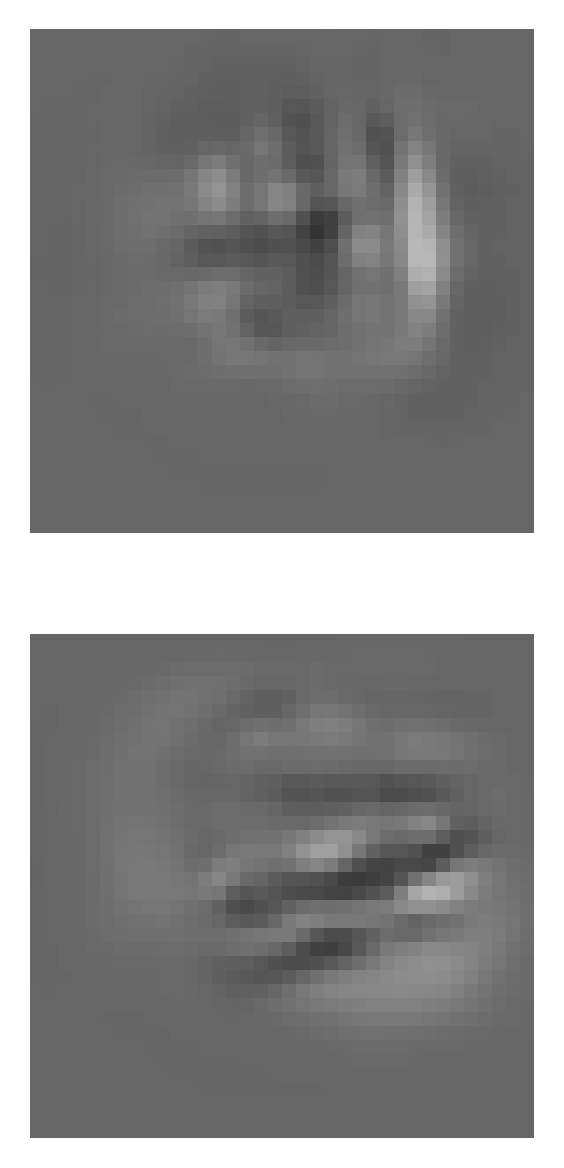

In [5]:
fig, axs = plt.subplots(G_visual_nrows, G_visual_ncols, dpi=300)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(model.patterns[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

(0.0, 2.0, 2.0, 0.0)

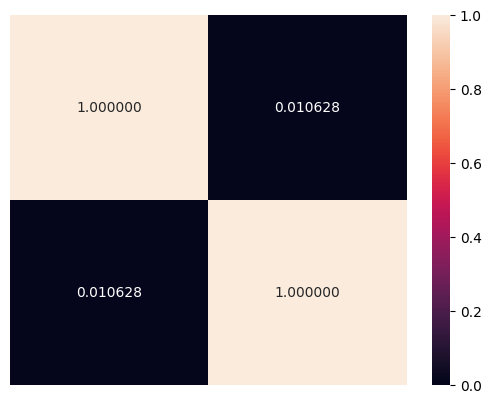

In [6]:
fig, ax = plt.subplots()
sns.heatmap(cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1)), annot=True, fmt="f", ax=ax, vmin=0, vmax=1)
# im = ax.imshow(cosine_similarity(model.gratings[-G_dim:].reshape(model.gratings.shape[0], -1)), cmap="seismic", vmin=-1, vmax=1)
# plt.colorbar(im, ax=ax)
plt.axis('off')

(-0.5, 17.5, 1.5, -0.5)

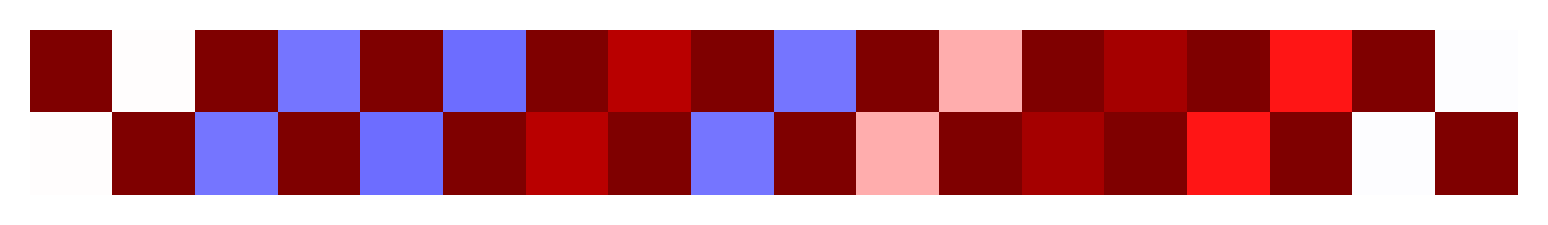

In [7]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.axis('off')

Text(0.5, 1.0, 'G-X mapping histogram')

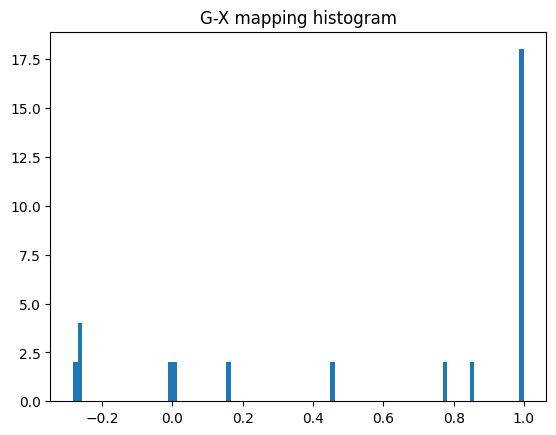

In [8]:
plt.hist(model.G_X_mapping.ravel(), bins=100)
# add title 
plt.title("G-X mapping histogram")

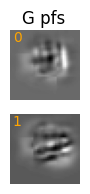

In [9]:
model.visualize_learned_G(nrows=G_visual_nrows, ncols=G_visual_ncols)

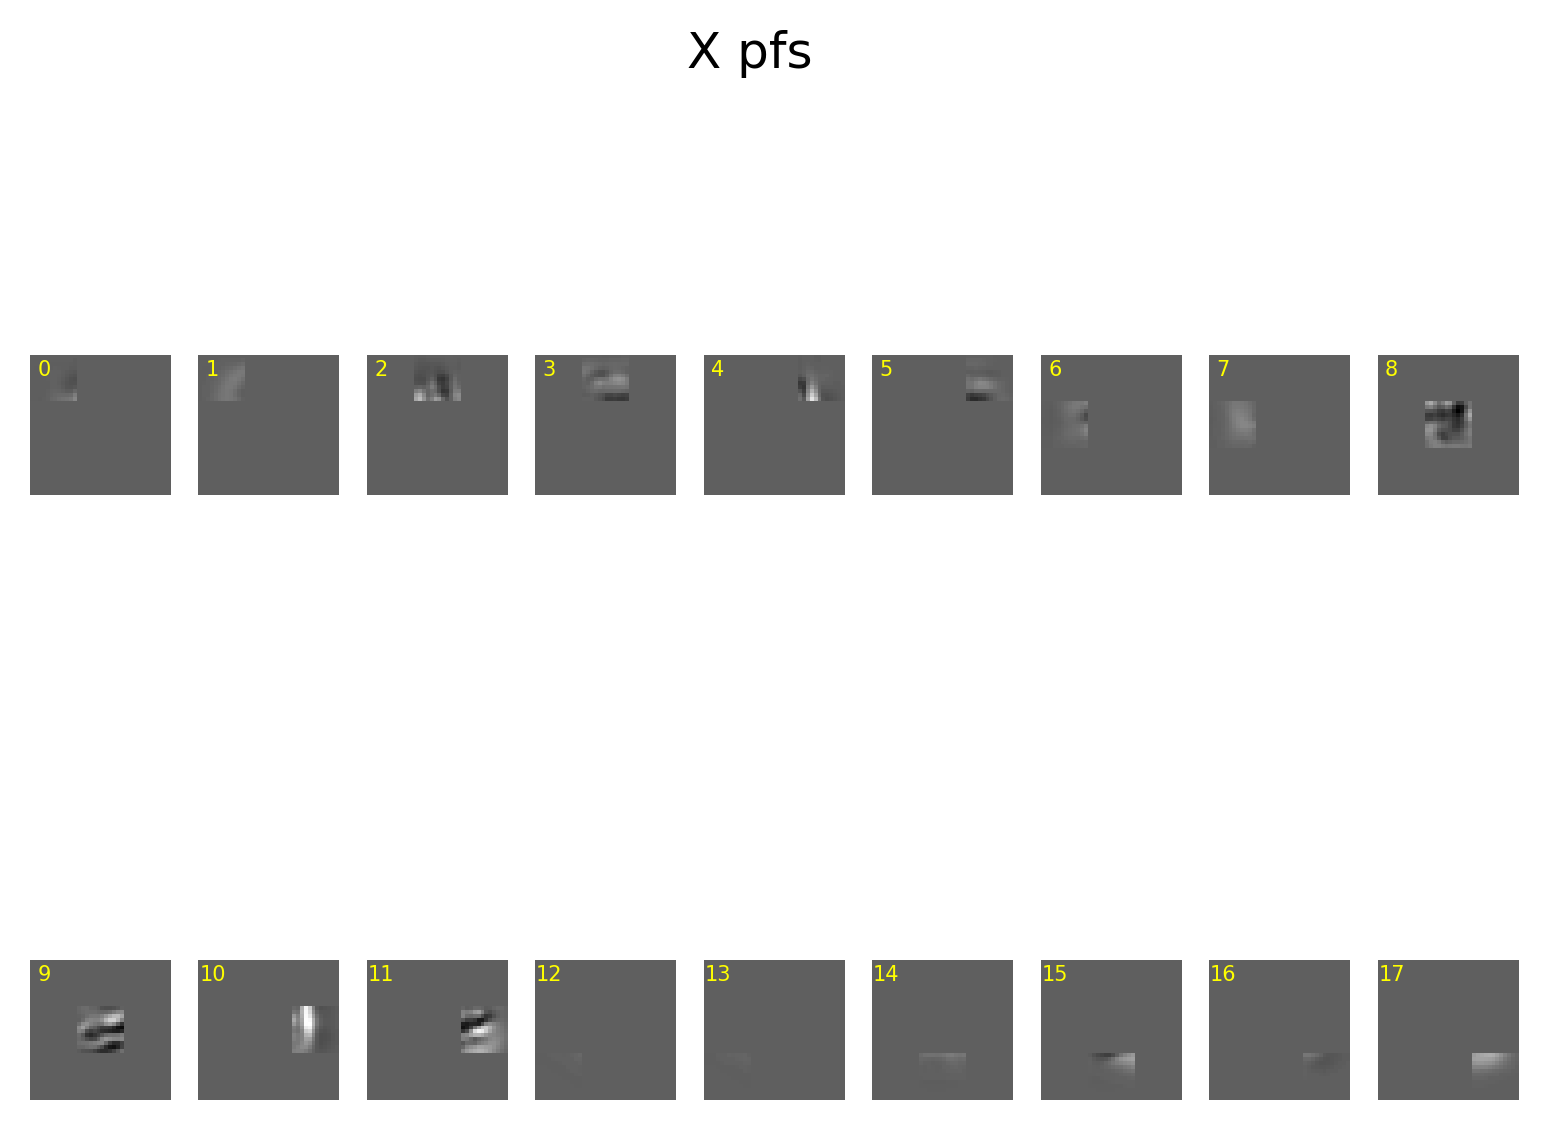

In [10]:
model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

In [11]:
4 * 3

12

In [12]:
total_center_x_dims = G_dim
center_x_ids = np.arange(4 * G_dim, 4 * G_dim + total_center_x_dims)

In [13]:
center_x_ids

array([8, 9])

In [14]:
center_x_ids

array([8, 9])

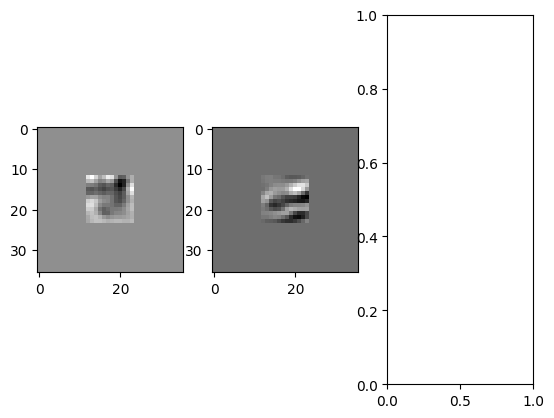

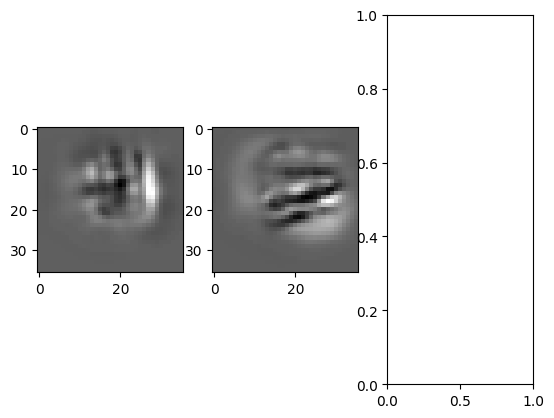

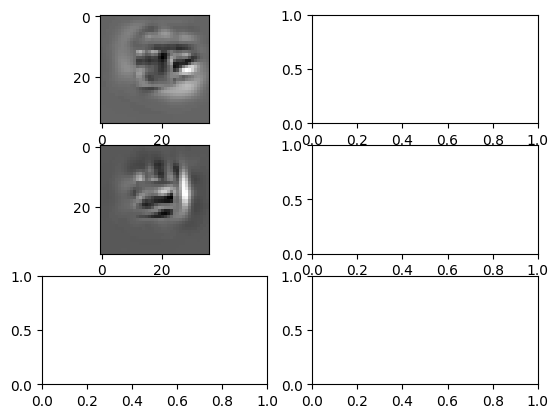

In [15]:
fig, axs = plt.subplots(1, 3)
fig_2, axs_2 = plt.subplots(1, 3)
fig_3, axs_3 = plt.subplots(3, 2)
for idx, center_x_id in enumerate(center_x_ids):
    MEI = np.zeros((36, 36))
    MEI_center = model.pattern_crops[4][idx].reshape(12, 12).copy()
    MEI[12:24, 12:24] = MEI_center.copy()
    axs.flatten()[idx].imshow(MEI, cmap="gray")
    completing_pattern = model.patterns[idx].copy()
    axs_2.flatten()[idx].imshow(completing_pattern, cmap="gray")
    disrupting_patterns = []
    for disrupting_idx, disrupting_id in enumerate([i for i in range(G_dim) if i != idx]):
        disrupting_pattern = model.patterns[disrupting_id].copy()
        disrupting_pattern[12:24, 12:24] = MEI_center.copy()
        disrupting_patterns.append(disrupting_pattern)
        axs_3[idx][disrupting_idx].imshow(disrupting_pattern, cmap="gray")
    
    # break
    

(-0.5, 35.5, 35.5, -0.5)

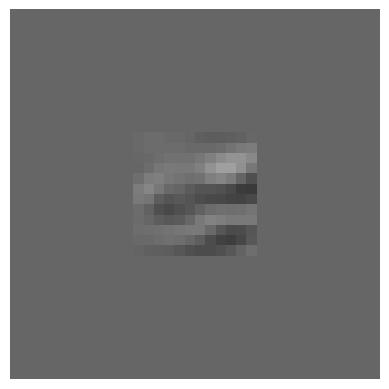

In [16]:
empty_image = np.zeros((36, 36))
empty_image[12:24, 12:24] = model.pattern_crops[4][1].reshape(12, 12).copy()
MEI_center = model.pattern_crops[4][1].reshape(12, 12).copy()
MEI = empty_image
plt.imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

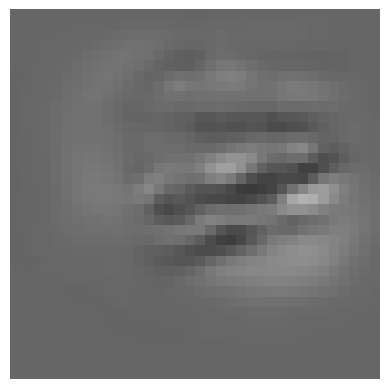

In [17]:
completing = model.patterns[1].copy()
plt.imshow(completing, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

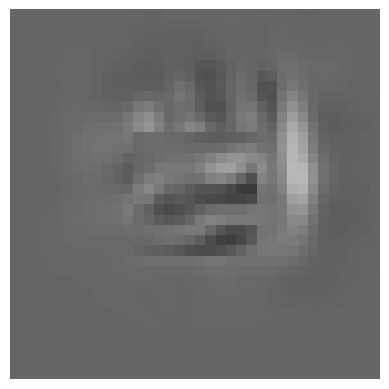

In [18]:
disrupting = model.patterns[0].copy()
disrupting[12:24, 12:24] = MEI_center.copy()
plt.imshow(disrupting, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

In [19]:
images = [MEI, completing, disrupting]
all_samples = []
for image in images:
    post_samples = model.sample_posterior(
        image=image,
        n_samples=n_draws,
        random_seed=42,
        tune=n_tune,
        chains=n_chains,
        cores=n_draws
    )

    all_samples.append(post_samples)

Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 50 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 6 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 50 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 6 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 50 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 5 seconds.
The number of samples is too small to check convergence reliably.


In [20]:
all_samples[0]['posterior']["X"].data.shape

(4, 50, 18)

In [21]:
n_neurons = G_dim * 9
all_x_samples_reshaped = []
for samples in all_samples:
    samples = samples['posterior']['X'].data.reshape(n_chains*n_draws, n_neurons)
    all_x_samples_reshaped.append(samples)

In [22]:
x_samples_chained = []
for samples in all_samples:
    samples = samples['posterior']['X'].data
    x_samples_chained.append(samples)

In [23]:
x_samples_chained[0].shape

(4, 50, 18)

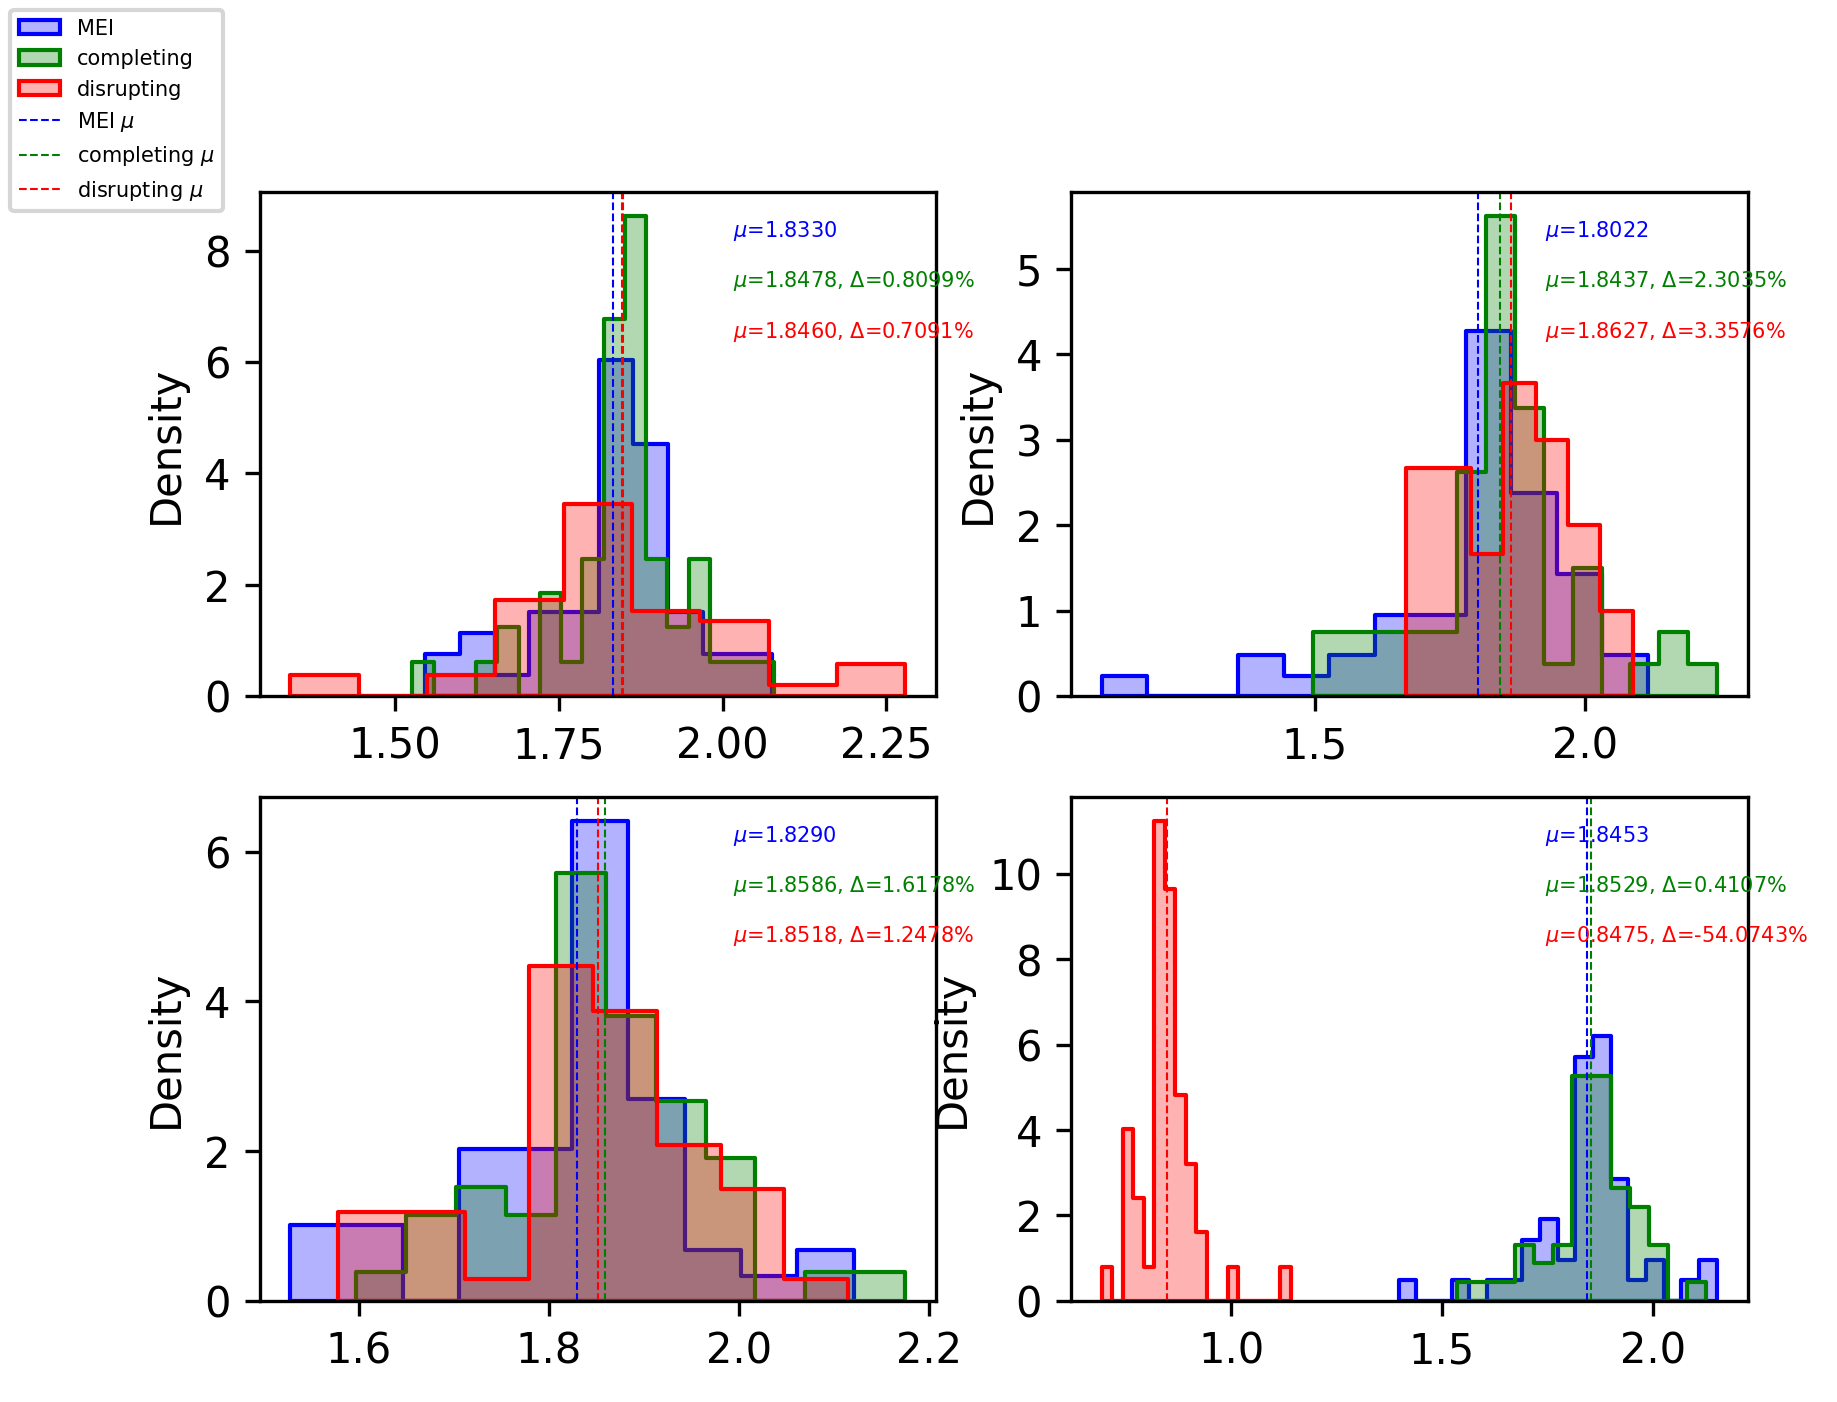

In [24]:
fig, axs = plt.subplots(nrows=2, ncols=2, dpi=300)
neuron_id = 13
for idx, ax in enumerate(axs.flatten()):
    mei_samples = x_samples_chained[0][idx][:, neuron_id]
    completing_samples = x_samples_chained[1][idx][:, neuron_id]
    disrupting_samples = x_samples_chained[2][idx][:, neuron_id]
    sns.histplot(
        mei_samples,
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.3,
        label="MEI"
    )
    sns.histplot(
        completing_samples,
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.3,
        label="completing"
    )
    sns.histplot(
        disrupting_samples,
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.3,
        label="disrupting"
    )

    MEI_mean = np.mean(mei_samples)
    completing_mean = np.mean(completing_samples)
    disrupting_mean = np.mean(disrupting_samples)
    completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
    disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

    ax.text(0.7, 0.9, f"$\mu$={MEI_mean:.4f}", size=5, ha="left", va="bottom", transform=ax.transAxes, color='blue')
    ax.text(0.7, 0.8, f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.4f}%", size=5, ha="left", va="bottom", transform=ax.transAxes, color='green')
    ax.text(0.7, 0.7, f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.4f}%", size=5, ha="left", va="bottom", transform=ax.transAxes, color='red')

    ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
    ax.axvline(completing_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
    ax.axvline(disrupting_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting $\mu$")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', prop={'size': 5})

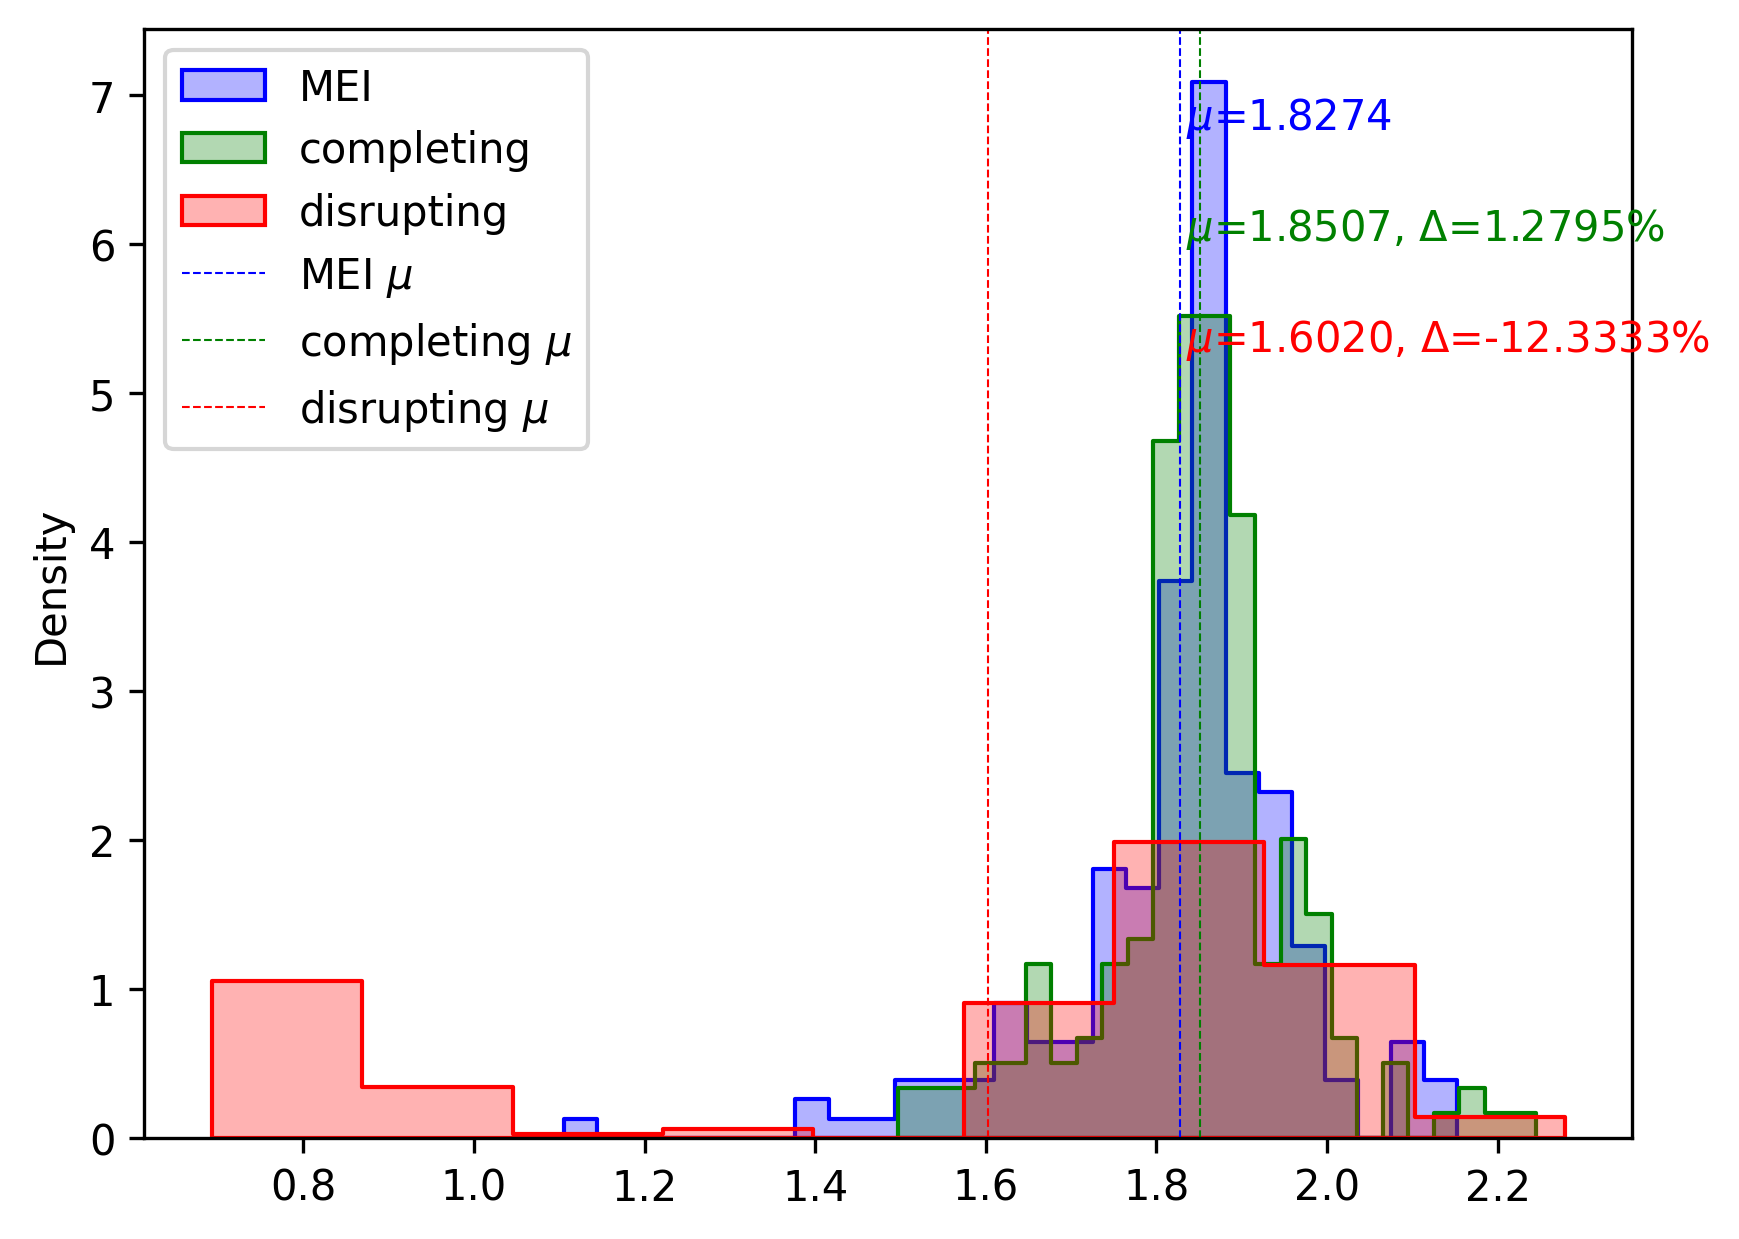

In [25]:
fig, ax = plt.subplots(dpi=300)
neuron_id = 13
sns.histplot(
    all_x_samples_reshaped[0][:, neuron_id],
    ax=ax,
    stat="density",
    color="blue",
    element="step",
    alpha=0.3,
    label="MEI"
)
sns.histplot(
    all_x_samples_reshaped[1][:, neuron_id],
    ax=ax,
    stat="density",
    color="green",
    element="step",
    alpha=0.3,
    label="completing"
)
sns.histplot(
    all_x_samples_reshaped[2][:, neuron_id],
    ax=ax,
    stat="density",
    color="red",
    element="step",
    alpha=0.3,
    label="disrupting"
)

MEI_mean = np.mean(all_x_samples_reshaped[0][:, neuron_id])
completing_mean = np.mean(all_x_samples_reshaped[1][:, neuron_id])
disrupting_mean = np.mean(all_x_samples_reshaped[2][:, neuron_id])
completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

ax.text(0.7, 0.9, f"$\mu$={MEI_mean:.4f}", size=10, ha="left", va="bottom", transform=ax.transAxes, color='blue')
ax.text(0.7, 0.8, f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.4f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='green')
ax.text(0.7, 0.7, f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.4f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='red')

ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
ax.axvline(completing_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
ax.axvline(disrupting_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting $\mu$")

ax.legend(loc="upper left")

In [30]:
all_samples[0]['posterior']['G'].data.shape

(4, 50, 2)

In [26]:
all_samples[0]['posterior']['G'].data.mean(axis=1)

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.]])

In [27]:
# completing
all_samples[1]['posterior']['G'].data.mean(axis=1)

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 1.]])

In [28]:
all_samples[2]['posterior']['G'].data.mean(axis=1)

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       [1., 0.]])